In [61]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("card_transdata.csv")

## Overview and Descriptive Statistics

In [62]:
df.head()

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
0,57.877857,0.311140,1.945940,1.0,1.0,0.0,0.0,0.0
1,10.829943,0.175592,1.294219,1.0,0.0,0.0,0.0,0.0
2,5.091079,0.805153,0.427715,1.0,0.0,0.0,1.0,0.0
3,2.247564,5.600044,0.362663,1.0,1.0,0.0,1.0,0.0
4,44.190936,0.566486,2.222767,1.0,1.0,0.0,1.0,0.0


In [63]:
df.shape

(1000000, 8)

In [64]:
df.dtypes

distance_from_home                float64
distance_from_last_transaction    float64
ratio_to_median_purchase_price    float64
repeat_retailer                   float64
used_chip                         float64
used_pin_number                   float64
online_order                      float64
fraud                             float64
dtype: object

In [65]:
df[df.duplicated()]

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud


In [66]:
df.isna().sum() # Hmmmm no N/A values either

distance_from_home                0
distance_from_last_transaction    0
ratio_to_median_purchase_price    0
repeat_retailer                   0
used_chip                         0
used_pin_number                   0
online_order                      0
fraud                             0
dtype: int64

In [67]:
df.describe()

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,26.628792,5.036519,1.824182,0.881536,0.350399,0.100608,0.650552,0.087403
std,65.390784,25.843093,2.799589,0.323157,0.477095,0.300809,0.476796,0.282425
min,0.004874,0.000118,0.004399,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.878008,0.296671,0.475673,1.000000,0.000000,0.000000,0.000000,0.000000
50%,9.967760,0.998650,0.997717,1.000000,0.000000,0.000000,1.000000,0.000000
75%,25.743985,3.355748,2.096370,1.000000,1.000000,0.000000,1.000000,0.000000
max,10632.723672,11851.104565,267.802942,1.000000,1.000000,1.000000,1.000000,1.000000


Below is just a glance at the categorical features.

In [68]:
boolean_features = ["repeat_retailer", "used_chip", "used_pin_number", "online_order", "fraud"]
for feature in boolean_features:
    f_sum = df[feature].sum()
    count = df[feature].count() 
    print(f"Feature \"{feature}\":")
    print(f"\t{int(f_sum)} TRUE values ({(f_sum / count) * 100: .2f}% )")
    print(f"\t{int(count - f_sum)} FALSE values ({((count - f_sum) / count) * 100: .2f}% )")

Feature "repeat_retailer":
	881536 TRUE values ( 88.15% )
	118464 FALSE values ( 11.85% )
Feature "used_chip":
	350399 TRUE values ( 35.04% )
	649601 FALSE values ( 64.96% )
Feature "used_pin_number":
	100608 TRUE values ( 10.06% )
	899392 FALSE values ( 89.94% )
Feature "online_order":
	650552 TRUE values ( 65.06% )
	349448 FALSE values ( 34.94% )
Feature "fraud":
	87403 TRUE values ( 8.74% )
	912597 FALSE values ( 91.26% )


## Visualizations

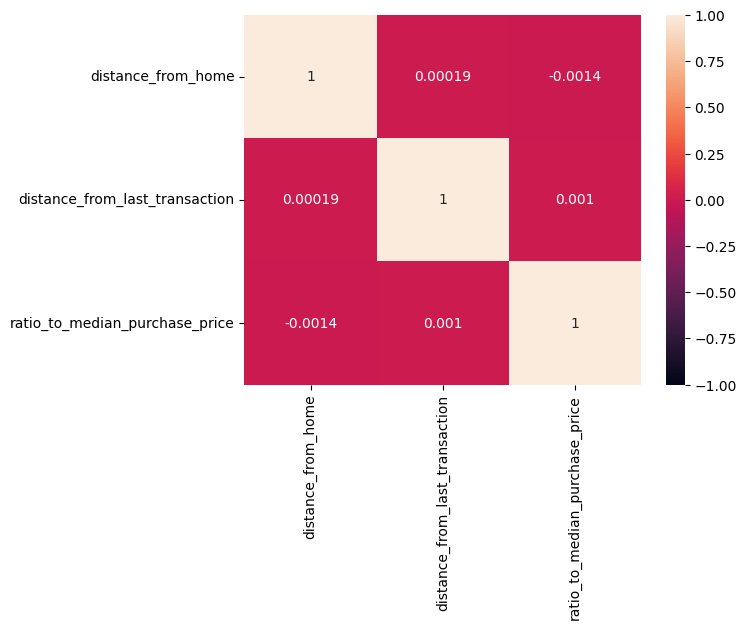

In [69]:
from sklearn.preprocessing import StandardScaler
df_numerical = df.drop(columns=boolean_features)
df_numerical.iloc[:, :] = StandardScaler().fit_transform(df_numerical)
ax = sns.heatmap(df_numerical.corr(), annot=True, vmin=-1, vmax=1)

In [70]:
df[['distance_from_home', 'distance_from_last_transaction','ratio_to_median_purchase_price']].skew()

distance_from_home                 20.239733
distance_from_last_transaction    125.921226
ratio_to_median_purchase_price      8.915015
dtype: float64

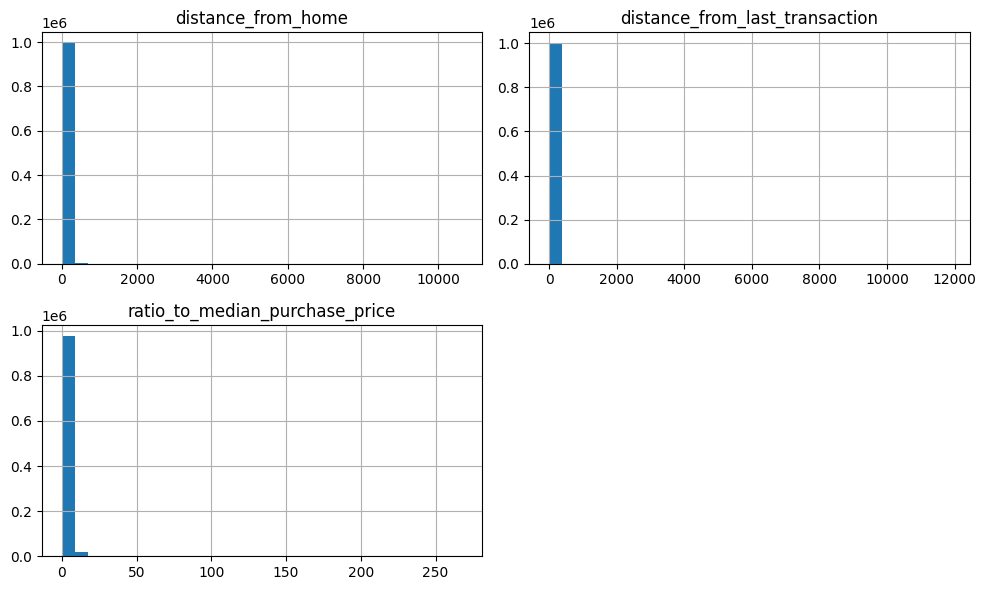

In [71]:
import matplotlib.pyplot as plt
df[['distance_from_home', 'distance_from_last_transaction','ratio_to_median_purchase_price']].hist(bins=30, figsize=(10, 6))
plt.tight_layout()
plt.show()

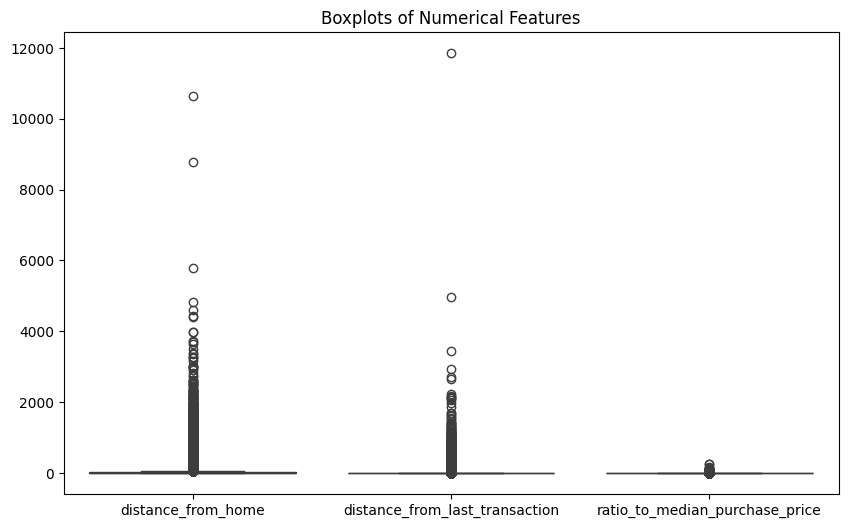

In [72]:
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[['distance_from_home', 'distance_from_last_transaction','ratio_to_median_purchase_price']])
plt.title("Boxplots of Numerical Features")
plt.show()

In [73]:
df.groupby("fraud")[["distance_from_home", "distance_from_last_transaction", "ratio_to_median_purchase_price"]].mean()

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price
fraud,,,
0.0,22.832976,4.301391,1.423642
1.0,66.261876,12.712185,6.006323


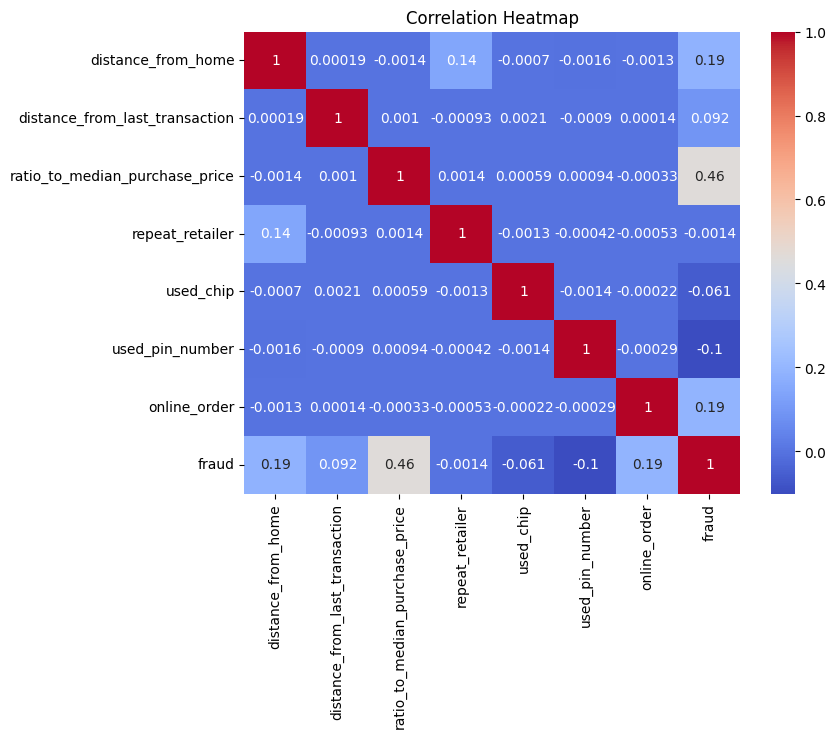

In [74]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

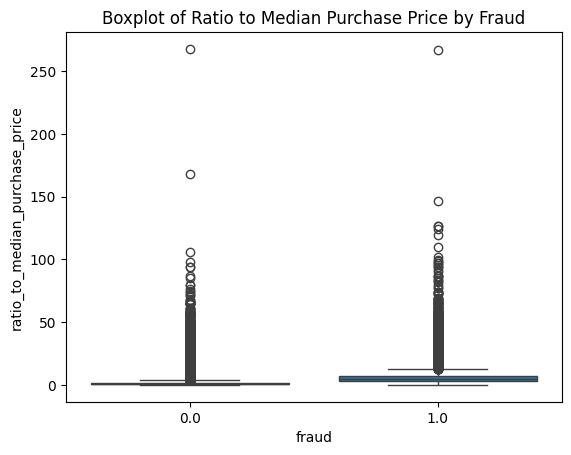

In [81]:
sns.boxplot(x="fraud", y="ratio_to_median_purchase_price", data=df)
plt.title("Boxplot of Ratio to Median Purchase Price by Fraud")
plt.show()

In [75]:
df.groupby("fraud")["online_order"].mean()

fraud
0.0    0.622225
1.0    0.946318
Name: online_order, dtype: float64

In [76]:
df.groupby("fraud")[["used_chip", "used_pin_number"]].mean()

,used_chip,used_pin_number
fraud,,
0.0,0.359402,0.109944
1.0,0.256399,0.003123


In [77]:
df.groupby("fraud")["repeat_retailer"].mean()

fraud
0.0    0.881672
1.0    0.880119
Name: repeat_retailer, dtype: float64

## Random Forest and XGBoost

In [78]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

X = df.drop("fraud", axis=1)
y = df["fraud"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test)
print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Random Forest Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

/Users/gracerobinson/.pyenv/versions/3.11.5/lib/python3.11/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


Random Forest Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      0.11      0.20    182519
         1.0       0.10      1.00      0.18     17481

    accuracy                           0.19    200000
   macro avg       0.55      0.55      0.19    200000
weighted avg       0.92      0.19      0.20    200000

Random Forest Accuracy: 0.18774
Random Forest Confusion Matrix:
[[ 20082 162437]
 [    15  17466]]


In [79]:
xgboost_model = XGBClassifier(n_estimators=100, random_state=42, scale_pos_weight=(len(y_train)/sum(y_train)), learning_rate=0.1, max_depth=6, use_label_encoder=False, eval_metric='logloss')
xgboost_model.fit(X_train_scaled, y_train)

y_pred_xgboost = xgboost_model.predict(X_test)
print("XGBoost Classification Report:")
print(classification_report(y_test, y_pred_xgboost))
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgboost))
print("XGBoost Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgboost))

/Users/gracerobinson/.pyenv/versions/3.11.5/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [02:56:43] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      0.11      0.19    182519
         1.0       0.10      1.00      0.18     17481

    accuracy                           0.18    200000
   macro avg       0.55      0.55      0.18    200000
weighted avg       0.92      0.18      0.19    200000

XGBoost Accuracy: 0.18404
XGBoost Confusion Matrix:
[[ 19327 163192]
 [     0  17481]]


## Data Quality 